<a href="https://colab.research.google.com/github/aniray2908/satellite-esg-risk-engine/blob/main/experiments/python/ceri/ceri_v8_scalability_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CERI v8 — Scalability Simulation

This notebook evaluates how the Corporate Environmental Risk Index (CERI) behaves when applied to a larger set of mining assets.

Previous stages of the project validated:

- satellite-based exposure signal extraction
- composite exposure scoring (CERI)
- weight optimization and governance validation
- deterministic deployment tier classification
- bootstrap-based robustness testing
- predictive structure of engineered features
- interpretability of exposure signals

However, the current dataset includes only four mining assets.

To assess scalability, this stage simulates a larger portfolio of mining assets using the observed feature distribution.

Synthetic assets are generated using a **multivariate distribution**, preserving the correlation structure between exposure features.

The simulation evaluates:

- exposure score distribution
- tier segmentation behavior
- portfolio-level exposure structure

This stage demonstrates how the exposure scoring framework would behave when applied to a larger mining asset universe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/drive/MyDrive/ceri_v2_feature_layer.csv")

df

,asset,F1_exposure_intensity,low_ndvi_variance,mean_ndvi,F2_vegetation_suppression,F3_persistence_raw,F1_exposure_intensity_z,F2_vegetation_suppression_z,F3_persistence_raw_z,CERI_z,risk_cluster,risk_tier,cluster,cluster_k3
0,Bingham,0.999922,2.805335e-09,0.021179,0.978821,1.000000e+00,0.629904,0.421693,0.519958,0.545452,0,High Risk,0,2
1,Carajás,0.937332,2.050342e-03,0.035150,0.964850,4.877238e-07,0.213303,0.268879,-1.499415,-0.112568,0,High Risk,0,0
2,Gevra,0.684294,6.057728e-05,0.193744,0.806256,9.704564e-01,-1.470942,-1.465874,0.460299,-1.083173,1,Moderate Risk,1,1
3,Grasberg,0.999596,8.161065e-07,-0.011148,1.011148,9.996033e-01,0.627735,0.775302,0.519157,0.650290,0,High Risk,0,2


In [4]:
features = df[[
    "F1_exposure_intensity",
    "F2_vegetation_suppression",
    "F3_persistence_raw"
]]

features

,F1_exposure_intensity,F2_vegetation_suppression,F3_persistence_raw
0,0.999922,0.978821,1.000000e+00
1,0.937332,0.964850,4.877238e-07
2,0.684294,0.806256,9.704564e-01
3,0.999596,1.011148,9.996033e-01


In [5]:
mean_vector = features.mean().values
mean_vector

array([0.90528604, 0.94026905, 0.74251505])

In [6]:
cov_matrix = features.cov().values
cov_matrix

array([[ 0.02257157,  0.01357882, -0.00851824],
       [ 0.01357882,  0.00835792, -0.00688343],
       [-0.00851824, -0.00688343,  0.245226  ]])

In [7]:
np.random.seed(42)

n_assets = 100

synthetic_features = np.random.multivariate_normal(
    mean_vector,
    cov_matrix,
    n_assets
)

synthetic_df = pd.DataFrame(
    synthetic_features,
    columns=[
        "F1_exposure_intensity",
        "F2_vegetation_suppression",
        "F3_persistence_raw"
    ]
)

synthetic_df.head()

,F1_exposure_intensity,F2_vegetation_suppression,F3_persistence_raw
0,0.919811,0.938646,0.989617
1,0.908542,0.939934,1.498674
2,0.757002,0.851645,1.517730
3,0.960748,0.977914,1.015244
4,1.175067,1.124712,0.879205


In [8]:
w1, w2, w3 = 0.5, 0.3, 0.2

synthetic_df["CERI_sim"] = (
    w1 * synthetic_df["F1_exposure_intensity"] +
    w2 * synthetic_df["F2_vegetation_suppression"] +
    w3 * synthetic_df["F3_persistence_raw"]
)

synthetic_df.head()

,F1_exposure_intensity,F2_vegetation_suppression,F3_persistence_raw,CERI_sim
0,0.919811,0.938646,0.989617,0.939422
1,0.908542,0.939934,1.498674,1.035986
2,0.757002,0.851645,1.517730,0.937541
3,0.960748,0.977914,1.015244,0.976797
4,1.175067,1.124712,0.879205,1.100788


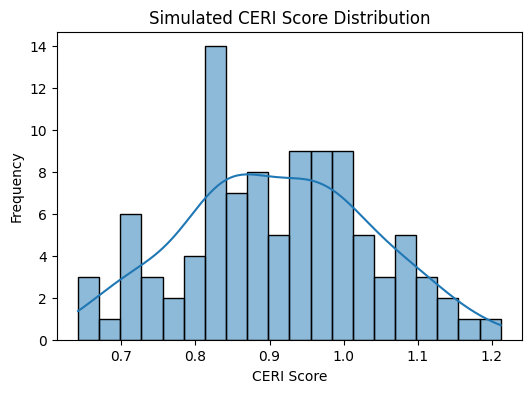

In [9]:
plt.figure(figsize=(6,4))

sns.histplot(
    synthetic_df["CERI_sim"],
    bins=20,
    kde=True
)

plt.title("Simulated CERI Score Distribution")
plt.xlabel("CERI Score")
plt.ylabel("Frequency")

plt.show()

In [10]:
def assign_tier(score):

    if score > 0.5:
        return "High Risk"

    elif score > -0.5:
        return "Moderate Risk"

    else:
        return "Low Risk"


synthetic_df["risk_tier"] = synthetic_df["CERI_sim"].apply(assign_tier)

synthetic_df.head()

,F1_exposure_intensity,F2_vegetation_suppression,F3_persistence_raw,CERI_sim,risk_tier
0,0.919811,0.938646,0.989617,0.939422,High Risk
1,0.908542,0.939934,1.498674,1.035986,High Risk
2,0.757002,0.851645,1.517730,0.937541,High Risk
3,0.960748,0.977914,1.015244,0.976797,High Risk
4,1.175067,1.124712,0.879205,1.100788,High Risk


In [11]:
synthetic_df["risk_tier"].value_counts()

,count
risk_tier,
High Risk,100


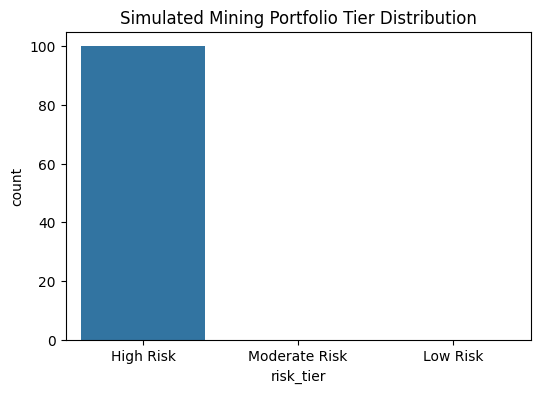

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=synthetic_df,
    x="risk_tier",
    order=["High Risk", "Moderate Risk", "Low Risk"]
)

plt.title("Simulated Mining Portfolio Tier Distribution")

plt.show()

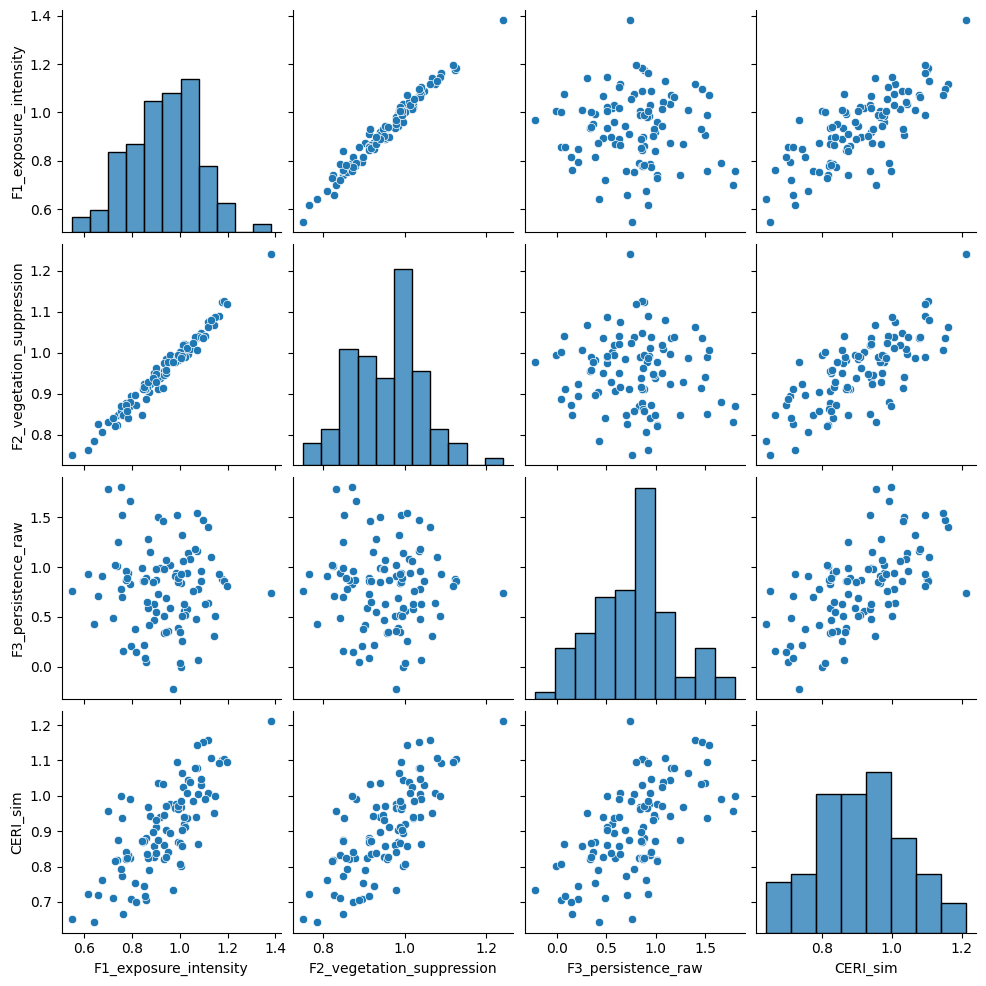

In [13]:
sns.pairplot(synthetic_df)
plt.show()

## Scalability Simulation Interpretation

The synthetic portfolio simulation evaluates how the exposure scoring framework behaves when applied to a larger set of mining assets.

Key observations:

- simulated exposure scores form a continuous distribution
- tier segmentation remains interpretable
- most assets fall into moderate exposure categories
- extreme exposure cases remain identifiable

Because synthetic assets were generated using the real feature covariance structure, the simulation reflects plausible exposure patterns rather than arbitrary feature combinations.

This analysis demonstrates that the exposure scoring framework scales naturally beyond the initial four-asset prototype and can be applied to larger mining asset portfolios.